In [135]:
import torch

# Tensors

In [136]:
# Number/Scalar

t1 = torch.tensor(4.)
t1


tensor(4.)

In [137]:
t1.dtype

torch.float32

In [138]:
#Vector
t2 = torch.tensor([1., 2, 3, 4])
t2

tensor([1., 2., 3., 4.])

In [139]:
# Matrix
t3 = torch.tensor([
    [5., 6],
    [7,8],
    [9,10]
])
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [140]:
# 3 dimensional array
t4 = torch.tensor([
    [
        [11, 12, 13],
        [14, 15, 16]
    ],
    [
        [17,18,19],
        [20,21,22]
    ]
])

t4

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])

In [141]:
t4.shape

torch.Size([2, 2, 3])

In [142]:
print(t1)
t1.shape

tensor(4.)


torch.Size([])

In [143]:
print(t2)
t2.shape

tensor([1., 2., 3., 4.])


torch.Size([4])

In [144]:
print(t3)
t3.shape

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])


torch.Size([3, 2])

In [145]:
print(t4)
t4.shape

tensor([[[11, 12, 13],
         [14, 15, 16]],

        [[17, 18, 19],
         [20, 21, 22]]])


torch.Size([2, 2, 3])

In [146]:
# Create tensors

x = torch.tensor(3.)
w = torch.tensor(4. , requires_grad = True)
b = torch.tensor(5., requires_grad = True)

x, w, b

(tensor(3.), tensor(4., requires_grad=True), tensor(5., requires_grad=True))

In [147]:
# Arithemitc operations

y = w*x + b
y

tensor(17., grad_fn=<AddBackward0>)

In [148]:
y

tensor(17., grad_fn=<AddBackward0>)

In [149]:
# Compute derivates
y.backward()

In [150]:
# Display gradients
print("dy/dx: " ,x.grad) # basic diffrentiation
print("dy/dw: ", w.grad)
print("dy/db: ", b.grad)


dy/dx:  None
dy/dw:  tensor(3.)
dy/db:  tensor(1.)


In [151]:
t3

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.]])

In [152]:
# Create a tensor with a fixed value for every elemnt

t6 = torch.full((3,2), 42)
t6

tensor([[42, 42],
        [42, 42],
        [42, 42]])

In [153]:
# Concatinate two tensors with compatible shapes
t7 = torch.cat((t3, t6))
t7

tensor([[ 5.,  6.],
        [ 7.,  8.],
        [ 9., 10.],
        [42., 42.],
        [42., 42.],
        [42., 42.]])

In [154]:
# change the sin of each element
t8 = torch.sin(t7)
t8

tensor([[-0.9589, -0.2794],
        [ 0.6570,  0.9894],
        [ 0.4121, -0.5440],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165],
        [-0.9165, -0.9165]])

In [155]:
t9 = torch.reshape(t8,(3,2,2))
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

In [156]:
# change the shape of a tensor

t9 = t8.reshape(3,2,2)
t9

tensor([[[-0.9589, -0.2794],
         [ 0.6570,  0.9894]],

        [[ 0.4121, -0.5440],
         [-0.9165, -0.9165]],

        [[-0.9165, -0.9165],
         [-0.9165, -0.9165]]])

In [157]:
import numpy as np
!pip install pandas
import pandas as pd

x = np.array([[1,2], [3, 4.]])
x


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


array([[1., 2.],
       [3., 4.]])

In [158]:
df=pd.DataFrame(x)
df

,0,1
0,1.0,2.0
1,3.0,4.0


In [159]:
y = torch.from_numpy(x)
y

tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)

In [160]:
x.dtype, y.dtype

(dtype('float64'), torch.float64)

In [161]:
z = y.numpy()
z

array([[1., 2.],
       [3., 4.]])

# Linear Regression from Scratch using pytorch

In [162]:
# Making training data
# Input ---> (temp, rainfall, humidity) ---> yield of apple and oranges crops

inputs = np.array([
    [73, 67,43],
    [91, 88, 64],
    [87, 134, 58],
    [102, 43, 37],
    [69, 96, 70],
], dtype = 'float32')

In [163]:
inputs

array([[ 73.,  67.,  43.],
       [ 91.,  88.,  64.],
       [ 87., 134.,  58.],
       [102.,  43.,  37.],
       [ 69.,  96.,  70.]], dtype=float32)

In [164]:
# Target (apples, oranges)

target = np.array([
    [56, 70],
    [81, 101],
    [119, 113],
    [22, 37],
    [103, 119]
], dtype = 'float32')

In [165]:
target

array([[ 56.,  70.],
       [ 81., 101.],
       [119., 113.],
       [ 22.,  37.],
       [103., 119.]], dtype=float32)

In [166]:
# Convert inputs and target to tensors

inputs = torch.from_numpy(inputs)
target = torch.from_numpy(target)

print(inputs)
print(target)



tensor([[ 73.,  67.,  43.],
        [ 91.,  88.,  64.],
        [ 87., 134.,  58.],
        [102.,  43.,  37.],
        [ 69.,  96.,  70.]])
tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])


In [167]:
# Weights and biases
w = torch.randn(2, 3, requires_grad = True)
b = torch.randn(2, requires_grad = True)

print(w)
print(b)


tensor([[-0.5443,  1.6065, -0.4889],
        [ 0.5487,  1.6511, -1.1197]], requires_grad=True)
tensor([ 0.9474, -0.2388], requires_grad=True)


In [168]:
# Z = X * W + B
def model(x):
  return x @ w.t() + b


#    y=x*w(transpose) + b
#   .t() makes the transpose.  @ performs matrix multiplication .. b adds as bias

In [169]:
'''


def modell(input):
    return x@w.t() +b 

pred=model(x)
def erros(y_act,y_pred):
    er=y_act-y_pred
    return er

erros(target,pred)


'''

'\n\n\ndef modell(input):\n    return x@w.t() +b \n\npred=model(x)\ndef erros(y_act,y_pred):\n    er=y_act-y_pred\n    return er\n\nerros(target,pred)\n\n\n'

In [170]:
# prediction
preds = model(inputs)
print(preds)

tensor([[ 47.8314, 102.2936],
        [ 61.5053, 123.3301],
        [140.5169, 203.8036],
        [ -3.5770,  85.2977],
        [ 83.3989, 117.7494]], grad_fn=<AddBackward0>)


In [171]:
# loss funtion we will use is MSE -> Mean squared error
def MSE(y, y_hat):
  diff = y - y_hat

  return torch.sum(diff*diff)/diff.numel()

In [172]:
# error
loss = MSE(target, preds)
print(loss)

tensor(1406.9169, grad_fn=<DivBackward0>)


In [173]:
#Compute gradients
loss.backward()

In [174]:
print(w)
print(w.grad)

tensor([[-0.5443,  1.6065, -0.4889],
        [ 0.5487,  1.6511, -1.1197]], requires_grad=True)
tensor([[-891.9384, -472.2174, -533.8720],
        [3425.8921, 3650.6292, 1956.7667]])


In [175]:
print(b)
print(b.grad)

tensor([ 0.9474, -0.2388], requires_grad=True)
tensor([-10.2649,  38.4949])


In [176]:
#reset grad
w.grad.zero_()
b.grad.zero_()

print(w.grad)
print(b.grad)

tensor([[0., 0., 0.],
        [0., 0., 0.]])
tensor([0., 0.])


In [177]:
# Adjust params

preds = model(inputs)

print(preds)


loss = MSE(target, preds)
print(loss)

tensor([[ 47.8314, 102.2936],
        [ 61.5053, 123.3301],
        [140.5169, 203.8036],
        [ -3.5770,  85.2977],
        [ 83.3989, 117.7494]], grad_fn=<AddBackward0>)
tensor(1406.9169, grad_fn=<DivBackward0>)


In [178]:
w

tensor([[-0.5443,  1.6065, -0.4889],
        [ 0.5487,  1.6511, -1.1197]], requires_grad=True)

In [179]:
loss.backward()

print(w.grad)
print(b.grad)

tensor([[-891.9384, -472.2174, -533.8720],
        [3425.8921, 3650.6292, 1956.7667]])
tensor([-10.2649,  38.4949])


In [180]:
# adjust weight & reset grad

learning_rate = 1e-5

with torch.no_grad():
  w -= w.grad * 1e-5
  b -= b.grad * 1e-5

  w.grad.zero_()
  b.grad.zero_()

In [181]:
print(w)
print(b)

tensor([[-0.5354,  1.6113, -0.4835],
        [ 0.5144,  1.6146, -1.1392]], requires_grad=True)
tensor([ 0.9475, -0.2391], requires_grad=True)


In [182]:
# Calculate again

preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(1131.8076, grad_fn=<DivBackward0>)


In [183]:
for i in range(400):
  preds = model(inputs)
  loss = MSE(target, preds)
  loss.backward()
  with torch.no_grad():
    w -= w.grad * 1e-5
    b -= b.grad * 1e-5

    w.grad.zero_()  # It sets all gradients of w to zero (in-place).
    b.grad.zero_()
  print(f"Epochs({i}/{400}) & Loss {loss}")

Epochs(0/400) & Loss 1131.8076171875
Epochs(1/400) & Loss 945.79248046875
Epochs(2/400) & Loss 819.8211059570312
Epochs(3/400) & Loss 734.3172607421875
Epochs(4/400) & Loss 676.0885620117188
Epochs(5/400) & Loss 636.2449951171875
Epochs(6/400) & Loss 608.7950439453125
Epochs(7/400) & Loss 589.7015380859375
Epochs(8/400) & Loss 576.2435302734375
Epochs(9/400) & Loss 566.5880126953125
Epochs(10/400) & Loss 559.4989013671875
Epochs(11/400) & Loss 554.143310546875
Epochs(12/400) & Loss 549.96044921875
Epochs(13/400) & Loss 546.5720825195312
Epochs(14/400) & Loss 543.7227783203125
Epochs(15/400) & Loss 541.2413330078125
Epochs(16/400) & Loss 539.0115356445312
Epochs(17/400) & Loss 536.9555053710938
Epochs(18/400) & Loss 535.0202026367188
Epochs(19/400) & Loss 533.1702880859375
Epochs(20/400) & Loss 531.3817138671875
Epochs(21/400) & Loss 529.6383056640625
Epochs(22/400) & Loss 527.9290161132812
Epochs(23/400) & Loss 526.24658203125
Epochs(24/400) & Loss 524.5858154296875
Epochs(25/400) & Lo

In [184]:
preds = model(inputs)
loss = MSE(target, preds)
print(loss)

tensor(231.1958, grad_fn=<DivBackward0>)


In [185]:
from math import sqrt
sqrt(loss)

15.205125165510086

In [186]:
preds

tensor([[ 57.7402,  68.7572],
        [ 75.7441,  86.7933],
        [132.4700, 142.2633],
        [ 22.8084,  46.5790],
        [ 89.8572,  91.1611]], grad_fn=<AddBackward0>)

In [187]:
target

tensor([[ 56.,  70.],
        [ 81., 101.],
        [119., 113.],
        [ 22.,  37.],
        [103., 119.]])

# Fashion MNIST Neural Net example using Pytorch

In [188]:
!pip install matplotlib


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [189]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda, Compose
import matplotlib.pyplot as plt


In [ ]:
# Download training data from open datasets

training_data = datasets.FashionMNIST(
    root = 'data',
    train= True,
    download = True,
    transform = ToTensor(),
)



test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download = True,
    transform = ToTensor(),
)

100.0%
100.0%
100.0%
100.0%


In [191]:
type(training_data)

torchvision.datasets.mnist.FashionMNIST

In [ ]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size = batch_size)
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
  print("Shape of X [N, C, H, W] ", X.shape)
  print("Shape of y: ", y.shape, y.dtype)
  break

Shape of X [N, C, H, W]  torch.Size([64, 1, 28, 28])
Shape of y:  torch.Size([64]) torch.int64


In [202]:
train_dataloader

In [193]:
# Get cpu or gpu device for training

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


In [194]:
# Define the NN Model
class NeuralNetwork(nn.Module):

  def __init__(self):
    super(NeuralNetwork, self).__init__()

    self.flatten = nn.Flatten()

    # Hidden Layers with ReLU activation function
    self.linear_relu_stack = nn.Sequential(
        nn.Linear(28*28, 512),
        nn.ReLU(),
        nn.Linear(512, 512),
        nn.ReLU(),
        nn.Linear(512, 10) # Output layer
    )

  def forward(self, x):
    x = self.flatten(x)
    logits = self.linear_relu_stack(x)
    return logits


model= NeuralNetwork().to(device)

print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [195]:
# Cross Entropy Loss ----> Because it is a multiclass classification problem

loss_fn = nn.CrossEntropyLoss()

# Optimizer ---> SGD ---> Stochastic Gradient Descent
# lr = Learning Rate
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [196]:
# Model Training

def train(dataloader, model, loss_fn, optimizer):
  size = len(dataloader.dataset)
  model.train()

  for batch, (X, y) in enumerate(dataloader):
    X, y= X.to(device), y.to(device) # related to gpu computation

    # Compute prediction error
    pred = model(X)
    loss = loss_fn(pred, y)

    # BackPropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if batch %100 ==0 :
      loss, current = loss.item(), batch * len(X)
      print(f"Loss: {loss} [{current}/{size}]")

In [197]:
def test(dataloader, model, loss_fn):
  size = len(dataloader.dataset)

  num_batches = len(dataloader)

  model.eval()

  test_loss, correct = 0, 0

  with torch.no_grad():
    for X, y in dataloader:
      X, y = X.to(device), y.to(device)
      pred = model(X)

      test_loss += loss_fn(pred, y).item()
      correct += (pred.argmax(1) == y).type(torch.float).sum().item()

  test_loss /= num_batches # average loss per batch
  correct /= size # %age of correct predictions or accuracy

  print(f"Test Error: \n Accuracy: {100*correct} %, Avg loss {test_loss}\n")




In [198]:
epochs = 1
for t in range(epochs):
  print(f"Epoch {t+1} \n --------------------------")
  train(train_dataloader, model, loss_fn, optimizer)
  test(test_dataloader, model, loss_fn)

print("Done\n")

Epoch 1 
 --------------------------
Loss: 2.316706418991089 [0/60000]
Loss: 2.302356719970703 [6400/60000]
Loss: 2.2787539958953857 [12800/60000]
Loss: 2.2677793502807617 [19200/60000]
Loss: 2.2601370811462402 [25600/60000]
Loss: 2.2325217723846436 [32000/60000]
Loss: 2.2353992462158203 [38400/60000]
Loss: 2.209940195083618 [44800/60000]
Loss: 2.212862253189087 [51200/60000]
Loss: 2.1732711791992188 [57600/60000]
Test Error: 
 Accuracy: 47.980000000000004 %, Avg loss 2.1691885662686294

Done



In [199]:
#save model
torch.save(model.state_dict(), "model.pth")
print("Saved model state to model.pth")

Saved model state to model.pth


In [200]:
## Prediction

classes = [
    "T-shirt/top",

"Trouser",

"Pullover",

"Dress",

"Coat",

"Sandal",

"Shirt",

"Sneaker",

"Bag",

"Ankle boot"

]


model.eval()

x, y = test_data[10][0], test_data[10][1]
x = x.to(device)
# y = y.to(device)
with torch.no_grad():
  pred = model(x)
  predicted, actual = classes[pred[0].argmax(0)], classes[y]

  print(f"Predicted: {predicted} Actual: {actual}")




Predicted: Coat Actual: Coat


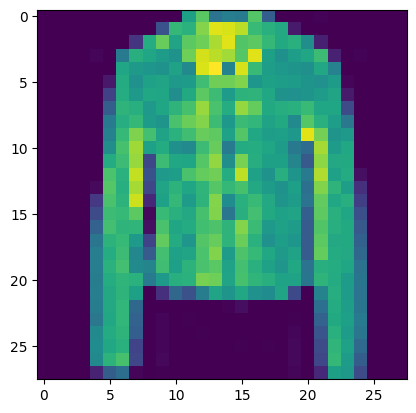

In [201]:
import matplotlib.pyplot as plt

# Assuming 'x' contains the image data
plt.imshow(x.cpu().squeeze())  # Move tensor to CPU if using GPU
plt.show()